In this notebook we create the FRISIA parameters for any aggregation of coastal segments from the SLIIDERS dataset. Sections that have to be adapted for creating a new type of aggregation are marked by

#ADAPTME >>>>

...

#ADAPTME <<<<

There are only two such sections within this notebook. The rest of it runs independently.

The default settings here create the "SLIIDERS_regional" parameters, which are already available in the repository

In [1]:
#ADAPTME >>>>
inputFRISIA = '../input/'

# World Bank regions are used here as an example 
AggregationName = 'SLIIDERS_regional'
nreg=7

# population density in potentially susceptible people (i.e. living below a 1000-year flood height + 3m)
# per km coastline, below which segments will be ignored.
popdens_limit = 50.0


# Choose scenarios for which to display example data here and create a csv with GDP and pop data in 
# order to later run FRISIA with it
scenarios = ['ssp126', 'ssp245', 'ssp370', 'ssp460', 'ssp585']
nsce = len(scenarios)

# This means that input data will be extended beyond 2100 with a decreasing growth rate
# (decreasing to 0 over 50 years for population and over 100 years for GDP and capital)
# If deactivated this will use the standard extension with constant values from 2100.
# -> Modifying this will only affect the file that includes socio-economic variables
#    used to drive FRISIA. The aggregation parameters itself are unaffected.
new_SSP_extension = True

#ADAPTME <<<<

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
from netCDF4 import Dataset
from joblib import Parallel, delayed
import sys
sys.path.append('../')
from src.SLRModel import globalSLRModel
import requests
import time as timer
from helpers import *

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
##### Loading SLIIDERS input
# return periods: 10, 100, 1000, 10000 (N=4)
# elevations: 0.05, 0.15, ... , 19.95 (midpoints, N=200)
# lats: -59.45 to 72.46 / lons: -179.99 to 179.95
# n_segs = 11980
# n_countries = 211
# n_ssps = 5 [1,2,3,4,5]
# n_years = 101 [2000-2100]
# n_IAMs = 2 ['IIASA', 'OECD']
# n_return_periods = 4 [10, 100, 1000, 10000]
# coastline length: [0.0, 6398.246], mean: 62.6
#
# data year for capital and pop: 2019
# SLD: SLIIDERS
n_time = 101
n_time_ext = 201
n_ssp = 5

# time array
time = np.linspace(2000,2200,n_time_ext)

print('Loading from dataset')

# Reading the sliiders file directly from Zenodo
ds = Dataset('sliiders-v1.2.nc',
                mode='r',
                memory=requests.get(
                    'https://zenodo.org/records/10779331/files/sliiders-v1.2.nc?download=1',
                    timeout=30).content)


# loading segment information
seg_lons = ds.variables['seg_lon'][:]
seg_lats = ds.variables['seg_lat'][:]
seg_length = ds.variables['length'][:]
n_segs = len(seg_length)
seg_region = ds.variables['seg_country'][:]

# loading elevations
elevations = ds.variables['elev'][:]
n_elev = len(elevations)
d_elev = elevations[1] - elevations[0]

# loading capital and population densities (data from 2019) [seg, elev]
pop_init = ds.variables['pop_2019'][:,:]
cap_init = ds.variables['K_2019'][:,:]

# loading time-varying socio-economic variables [year, country, ssp, iam]
# (use only OECD as IAM, because Depsky et al. (2023) describe some implausible data for IIASA capital growth)
# iam dimension not given for pop, only for GDP and capital
reg_pop_scale = ds.variables['pop_scale'][:,:,:]
reg_cap_scale = ds.variables['K_scale'][:,:,:,1]
reg_ypcc = ds.variables['ypcc'][:,:,:,1]

# loading land area
area = ds.variables['landarea'][:,:]

# loading gumbel params
seg_gumbel = ds.variables['gumbel_params'][:,:]

# loading surge heights
seg_surges = ds.variables['surge_height'][:,:]

# loading other
reg_pc = ds.variables['pc'][:]
reg_mobcapfrac = ds.variables['mobcapfrac'][:]
regions = ds.variables['country'][:]

ds.close()

print('...loading done')
print('Creating segment-level socio-economic variables for SLIIDERS')




## preprocessing data onto the segment level
seg_ireg = np.zeros((n_segs))
seg_pop = np.zeros((n_time_ext, n_segs, n_ssp))
seg_pop_scale = np.zeros((n_time_ext, n_segs, n_ssp))
seg_cap = np.zeros((n_time_ext, n_segs, n_ssp))
seg_cap_scale = np.zeros((n_time_ext, n_segs, n_ssp))
seg_ypcc = np.zeros((n_time_ext, n_segs, n_ssp))

for iseg in range(n_segs):
    ireg = regions.tolist().index(seg_region[iseg])
    seg_ireg[iseg] = ireg
    
    seg_pop[:n_time,iseg,:] = np.sum(pop_init[np.newaxis,iseg,:,np.newaxis] * reg_pop_scale[:,ireg,np.newaxis,:], axis=1)
    seg_cap[:n_time,iseg,:] = np.sum(cap_init[np.newaxis,iseg,:,np.newaxis] * reg_cap_scale[:,ireg,np.newaxis,:], axis=1)
    
    seg_pop_scale[:n_time,iseg,:] = reg_pop_scale[:,ireg,:]
    seg_cap_scale[:n_time,iseg,:] = reg_cap_scale[:,ireg,:]
    
    seg_ypcc[:n_time,iseg,:] = reg_ypcc[:,ireg,:]
    
# scale initial pop and capital distributions with the SLIIDERS scale factor for using them directly later
pop_init = pop_init * seg_pop_scale[0,:,np.newaxis,0]
cap_init = cap_init * seg_cap_scale[0,:,np.newaxis,0]
    
if new_SSP_extension:
    constant_pop_in_years = 50
    constant_cap_in_years = 100
    constant_ypcc_in_years = 100
    
    seg_pop = extend_with_decreasing_growth(seg_pop, constant_pop_in_years, istart=100)
    seg_cap = extend_with_decreasing_growth(seg_cap, constant_cap_in_years, istart=100)
    seg_ypcc = extend_with_decreasing_growth(seg_ypcc, constant_ypcc_in_years, istart=100)
else:
    seg_pop[n_time:,...] = seg_pop[n_time-1,None,...]
    seg_cap[n_time:,...] = seg_cap[n_time-1,None,...]
    seg_ypcc[n_time:,...] = seg_ypcc[n_time-1,None,...]
    
seg_gdp = seg_pop * seg_ypcc    

print('... done')

print('Creating some processed segment-level and global data')

iyr = 25 # SLIIDERS starts in 2000, but we want 2025 as the start year to define our initial flood protection heights
FLOPROH = create_FLOPROH_SLIIDERS(seg_ypcc[iyr,:,0], cap_init, pop_init, seg_length,
                                      seg_gumbel, seg_surges)

seg_H_init = FLOPROH

susceptible_popdens = calc_flooding_SLIIDERS(seg_surges[:,2]+3, 0, pop_init) / seg_length
seg_mask = np.where(susceptible_popdens < popdens_limit, 0, np.where(seg_length==0., 0, 1))

surge10 = seg_surges[:,0]
surge100 = seg_surges[:,1]
surge1000 = seg_surges[:,2]
surge10000 = seg_surges[:,3]

global_pop = np.sum(seg_mask[np.newaxis,:,np.newaxis] * seg_pop, axis=1)
global_cap = np.sum(seg_mask[np.newaxis,:,np.newaxis] * seg_cap, axis=1)
global_gdp = np.sum(seg_mask[np.newaxis,:,np.newaxis] * seg_pop*seg_ypcc, axis=1)
global_coast_length = np.sum(seg_mask*seg_length)


#### Create the arrays of fit parameters that are filled during the following analysis
# Regional aggregation
fit_params_with_initial_dikes = np.zeros((nreg,7,8)) # 7 regions, 7 different fits, 4 parameters and 4 standard deviations each
fit_params_without_initial_dikes = np.zeros((nreg,7,6)) # same as above, different fits (also different fit function)

print('... done')

Loading from dataset
...loading done
Creating segment-level socio-economic variables for SLIIDERS
... done
Creating some processed segment-level and global data
... done


In [4]:
############## Creating SLR data ################################
########## FaIR input data for SLR model ########################
n = 3 # number of ensemble members, here we only have 3 for the 17th, 50th and 83rd percentiles from FaIR
nTime = 551
all_T1  = np.zeros((nTime, nsce, n))
all_ohc = np.zeros((nTime, nsce, n))

for isc, scenario in enumerate(scenarios):
    df = pd.read_csv(inputFRISIA+'FaIR/T_and_OHC_from_FaIRv2.1.1_calibrationv1.1.0_'+scenario+'.csv')

    all_T1[:,isc,:]  = df.values[:,1:4] - np.mean(df.values[100:150,np.newaxis,1:4], axis=0) # take anomaly to 1850-1900
    all_ohc[:,isc,:] = df.values[:,4:7] - np.mean(df.values[100:150,np.newaxis,4:7], axis=0)

all_ohc_change = np.append(np.zeros_like(all_ohc[0,np.newaxis,:,:]), all_ohc[1:,:,:] - all_ohc[:-1,:,:], axis=0)

T1_median = all_T1[:,:,0]
ohc_change_median = all_ohc_change[:,:,0]
T1_high = all_T1[:,:,2]
ohc_change_high = all_ohc_change[:,:,2]

############### Calculating SLR Model
SLR_total = np.zeros_like(T1_median)
SLR_thermo = np.zeros_like(T1_median)
SLR_MG = np.zeros_like(T1_median)
SLR_LWS = np.zeros_like(T1_median)
SLR_GIS = np.zeros_like(T1_median)
SLR_AIS = np.zeros_like(T1_median)


SLRModel = globalSLRModel(T1_median[:,1], ohc_change_median[:,1], dbg=0)

for sidx in range(nsce):
    print('Start calculating scenario '+scenarios[sidx])

    SLRModel.T_anomaly = T1_high[:,sidx] # Use upper end values here to increase fit range
    SLRModel.OHC_change = ohc_change_high[:,sidx] # as above
    SLRModel.reset_SLR()
    SLRModel.integrate()
    SLRModel.align(1993, silent=True)
        
    SLR_total[:,sidx] = SLRModel.getSLRTotal()
    SLR_thermo[:,sidx] = SLRModel.getSLRThermo()
    SLR_MG[:,sidx] = SLRModel.getSLRMG()
    SLR_LWS[:,sidx] = SLRModel.getSLRLWS()
    SLR_GIS[:,sidx] = SLRModel.getSLRGIS()
    SLR_AIS[:,sidx] = SLRModel.getSLRAIS()
    

fingerprint_file=inputFRISIA+'/FINGERPRINTS_SLANGEN_Bakker.nc'
ds = Dataset(fingerprint_file)
weights_MG = ds.variables['GLAC'][:,:]
weights_GIS = ds.variables['GIS'][:,:]
weights_AIS = ds.variables['AIS'][:,:]
ds.close()

# Reduce array to time between 2000 and 2200 (time frame of ssp-related data like GDP and pop)
si=250
ei=451

SLR_total = SLR_total[si:ei]
SLR_thermo = SLR_thermo[si:ei]
SLR_LWS = SLR_LWS[si:ei]
SLR_MG = SLR_MG[si:ei]
SLR_GIS = SLR_GIS[si:ei]
SLR_AIS = SLR_AIS[si:ei]

local_SLRs = np.zeros((len(SLR_total[:,0]), n_segs, nsce))
for sidx in range(nsce):
    print('Start calculating scenario '+scenarios[sidx])
    
    for i, lat in enumerate(seg_lats):
        lon = seg_lons[i]
        local_SLRs[:,i,sidx] = getLocalSLR(lat,
                                             lon,
                                             [SLR_thermo[:,sidx], SLR_LWS[:,sidx], SLR_MG[:,sidx], SLR_GIS[:,sidx], SLR_AIS[:,sidx]],
                                             [weights_MG, weights_GIS, weights_AIS])
        

Start calculating scenario ssp126
Start calculating scenario ssp245
Start calculating scenario ssp370
Start calculating scenario ssp460
Start calculating scenario ssp585
Start calculating scenario ssp126


/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:39: RuntimeWarning: Mean of empty slice
  wt_MG = np.nanmean(weights[0][ilat-shift:ilat+shift+1, ilon-shift:ilon+shift+1])
/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:40: RuntimeWarning: Mean of empty slice
  wt_GIS = np.nanmean(weights[1][ilat-shift:ilat+shift+1, ilon-shift:ilon+shift+1])
/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:41: RuntimeWarning: Mean of empty slice
  wt_AIS = np.nanmean(weights[2][ilat-shift:ilat+shift+1, ilon-shift:ilon+shift+1])


Start calculating scenario ssp245
Start calculating scenario ssp370
Start calculating scenario ssp460
Start calculating scenario ssp585


In [5]:
## create the weights for each segment:
seg_weights_MG = np.zeros(n_segs)
seg_weights_GIS = np.zeros(n_segs)
seg_weights_AIS = np.zeros(n_segs)
for i, lat in enumerate(seg_lats):
    lon = seg_lons[i]
    seg_weights_MG[i], seg_weights_GIS[i], seg_weights_AIS[i] = getlSLRweights(lat,lon,[weights_MG, weights_GIS, weights_AIS])
    

/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:59: RuntimeWarning: Mean of empty slice
  wt_MG = np.nanmean(weights[0][ilat-shift:ilat+shift+1, ilon-shift:ilon+shift+1])
/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:60: RuntimeWarning: Mean of empty slice
  wt_GIS = np.nanmean(weights[1][ilat-shift:ilat+shift+1, ilon-shift:ilon+shift+1])
/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:61: RuntimeWarning: Mean of empty slice
  wt_AIS = np.nanmean(weights[2][ilat-shift:ilat+shift+1, ilon-shift:ilon+shift+1])


# Data preparation for different aggregation levels

## Aggregation of data by GDP density

In [6]:
regional_pop = np.zeros((nreg,n_time_ext,nsce))
regional_cap = np.zeros((nreg,n_time_ext,nsce))
regional_gdp = np.zeros((nreg,n_time_ext,nsce))
regional_slr = np.zeros((nreg,n_time_ext,nsce))

coast_length_by_region = np.zeros((nreg))
dike_height_by_region = np.zeros((nreg))
surge10_by_region = np.zeros((nreg))
surge100_by_region = np.zeros((nreg))
surge1000_by_region = np.zeros((nreg))
surge10000_by_region = np.zeros((nreg))
nsegs_by_region = np.zeros((nreg))

regional_wt_MG = np.zeros((nreg))
regional_wt_GIS = np.zeros((nreg))
regional_wt_AIS = np.zeros((nreg))


#ADAPTME >>>>
# Change in the following code how the DIVA segments are classified into the regions. 
# Here using the World Bank regions an example.

### Loading world bank regions
df = pd.read_csv(inputFRISIA+'World_Bank_classification.csv')

wb_codes = df.values[:,1].tolist()
wb_regions = df.values[:,2].tolist()

region_names = ['North America', 'Latin America and Caribbean', 'Europe and Central Asia', 'Middle East and North Africa',
                   'Sub-Saharan Africa', 'South Asia', 'East Asia and Pacific']
seg_wb_region_list = []

regional_mask = np.zeros(n_segs,dtype=int)

for i, region in enumerate(seg_region):
    if not seg_mask[i]: continue
    
    # Some regions from SLIIDERS are not defined in World Bank data...
    if region in ['WLF', 'ESH']: # West bank and Gaza, Western Sahara
        seg_wb_region = 'Middle East and North Africa'
    elif region in  ['GLP', 'MTQ', 'ANT', 'GUF']: # Guadeloupe, Martinique, Netherl. Antilles, French Guiana
        seg_wb_region = 'Latin America and Caribbean'
    elif region in ['REU', 'ZNC', 'XAD', 'JEY', 'GGY', 'ALA', 'FLK', 'SHN', 'MYT', 'BES', 'SPM', 'AIA', 'BLM', 'MSR']: # La Réunion, Northern Cyprus, Southern Cyprus, Jersey, Guernsey, Aland (Sweden), Falkland, Saint Helena, Mayotte, "BES"-islands Saint Pierre and Miquelon, Anguilla, Saint Barthelemy, Montserrat
        seg_wb_region = 'Europe and Central Asia'
    elif region in ['COK', 'NIU', 'CXR', 'XPI', 'CCK', 'TKL']: # Cook Island, Niue, Christmas Island, Paracel Islands, Cocos Islands, Tokelau
        seg_wb_region = 'East Asia and Pacific'
    else:
        try:
            seg_wb_region = wb_regions[wb_codes.index(region)]
        except: 
            print(region, 'not found')
            print('  lat: '+str(int(seg_lats[i]))+'°'+str(np.round((seg_lats[i]-int(seg_lats[i]))*60,0))+'N') 
            print('  lon: '+str(int(seg_lons[i]))+'°'+str(np.round((seg_lons[i]-int(seg_lons[i]))*60,0))+'E') 
        
    seg_wb_region_list.append(seg_wb_region)    
    
    found = False
    for ireg, region_name in enumerate(region_names):
        if seg_wb_region == region_name:
            regional_mask[i] = ireg
            regional_pop[ireg,:,:] += seg_pop[:,i,:]
            regional_cap[ireg,:,:] += seg_cap[:,i,:]
            regional_gdp[ireg,:,:] += seg_gdp[:,i,:]
            regional_slr[ireg,:,:] += local_SLRs[:,i,:] * seg_pop[:,i,:]
            coast_length_by_region[ireg] += seg_length[i]
            dike_height_by_region[ireg] += seg_H_init[i] * seg_length[i]
            surge10_by_region[ireg] += surge10[i] * seg_length[i]
            surge100_by_region[ireg] += surge100[i] * seg_length[i]
            surge1000_by_region[ireg] += surge1000[i] * seg_length[i]
            surge10000_by_region[ireg] += surge10000[i] * seg_length[i]
            nsegs_by_region[ireg] += 1
            regional_wt_MG[ireg] += seg_weights_MG[i]*seg_pop[0,i,0]
            regional_wt_GIS[ireg] += seg_weights_GIS[i]*seg_pop[0,i,0]
            regional_wt_AIS[ireg] += seg_weights_AIS[i]*seg_pop[0,i,0]
            found = True
    
    if not found: sys.exit('The region "'+seg_wb_region+'" is not part of the seven pre-defined world regions!')

#ADAPTME <<<<  
        
regional_ypcc = regional_gdp / regional_pop
regional_slr = regional_slr / regional_pop
dike_height_by_region = dike_height_by_region / coast_length_by_region
surge10_by_region = surge10_by_region / coast_length_by_region
surge100_by_region = surge100_by_region / coast_length_by_region
surge1000_by_region = surge1000_by_region / coast_length_by_region
surge10000_by_region = surge10000_by_region / coast_length_by_region
surge1_by_region = surge10_by_region - (surge100_by_region - surge10_by_region)

regional_wt_MG = regional_wt_MG / regional_pop[:,0,0]
regional_wt_GIS = regional_wt_GIS / regional_pop[:,0,0]
regional_wt_AIS = regional_wt_AIS / regional_pop[:,0,0]

for ireg, region_name in enumerate(region_names):
    print(region_name+':')
    print('   # of segments:          ', nsegs_by_region[ireg])
    print('   mean dike height:       ', np.round(dike_height_by_region[ireg],2), ' m')
    print('   mean surge1 height:             ', np.round(surge1_by_region[ireg],2), ' m')
    print('   mean surge10 height:            ', np.round(surge10_by_region[ireg],2), ' m')
    print('   mean surge100 height:           ', np.round(surge100_by_region[ireg],2), ' m')
    print('   mean surge1000 height:          ', np.round(surge1000_by_region[ireg],2), ' m')
    print('   mean surge10000 height:         ', np.round(surge10000_by_region[ireg],2), ' m')
    print('   mean SLR (2200, SSP5-8.5): ', np.round(regional_slr[ireg,-1,-1],3), ' m')
    print('   mean SLR weight MG:       ', np.round(regional_wt_MG[ireg],3))
    print('   mean SLR weight GIS:      ', np.round(regional_wt_GIS[ireg],3))
    print('   mean SLR weight AIS:      ', np.round(regional_wt_AIS[ireg],3))
    print('   total coast length:     ', np.round(coast_length_by_region[ireg],1), ' km ('+str(round(coast_length_by_region[ireg]*100/global_coast_length, 1))+'%)')
    print('   initial population:     ', np.round(regional_pop[ireg,0,0]*1e-6, 1), ' Mp ('+str(round(regional_pop[ireg,0,0]*100/global_pop[0,0], 1))+'%)')
    print('   initial GDP:            ', np.round(regional_gdp[ireg,0,0]*1e-9, 1), ' billion USD ('+str(round(regional_gdp[ireg,0,0]*100/global_gdp[0,0], 1))+'%)')
    print('   initial GDP per capita: ', np.round(regional_ypcc[ireg,0,0], 1), 'USD / person')
    print()

North America:
   # of segments:           239.0
   mean dike height:        1.74  m
   mean surge1 height:              1.1  m
   mean surge10 height:             1.37  m
   mean surge100 height:            1.63  m
   mean surge1000 height:           1.88  m
   mean surge10000 height:          2.14  m
   mean SLR (2200, SSP5-8.5):  3.664  m
   mean SLR weight MG:        0.817
   mean SLR weight GIS:       0.721
   mean SLR weight AIS:       1.124
   total coast length:      21419.1  km (7.5%)
   initial population:      48.6  Mp (5.1%)
   initial GDP:             2416.2  billion USD (21.4%)
   initial GDP per capita:  49717.0 USD / person

Latin America and Caribbean:
   # of segments:           879.0
   mean dike height:        1.43  m
   mean surge1 height:              1.17  m
   mean surge10 height:             1.28  m
   mean surge100 height:            1.39  m
   mean surge1000 height:           1.49  m
   mean surge10000 height:          1.59  m
   mean SLR (2200, SSP5-8.5):  4

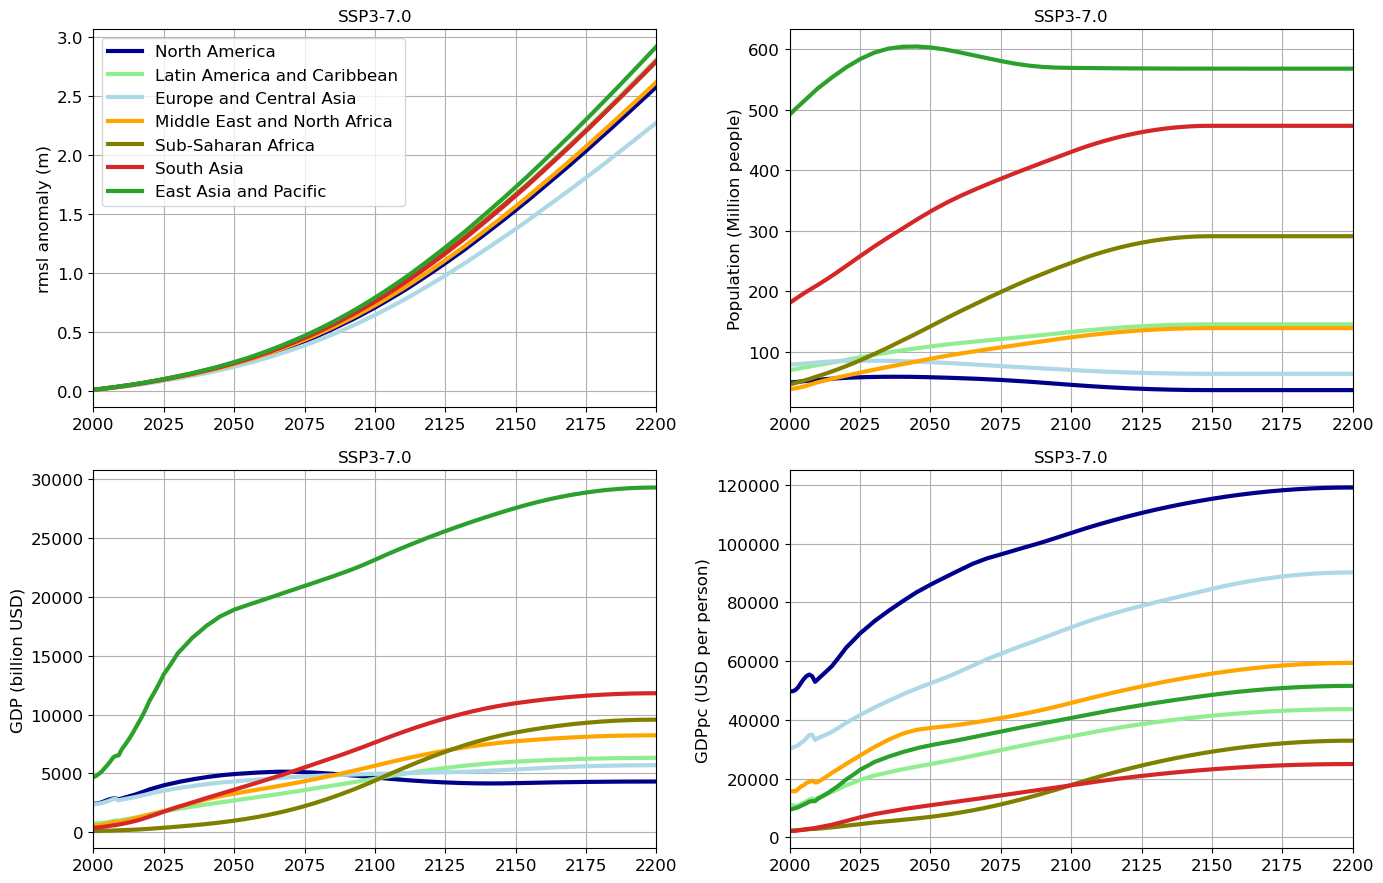

In [7]:
# region loop
colors = ['darkblue', 'lightgreen', 'lightblue', 'orange', 'olive', 'tab:red', 'tab:green']

# data/plot loop
data = [regional_slr, regional_pop[:,:,:]*1e-6, regional_gdp[:,:,:]*1e-9, regional_ypcc[:,:,:]]
ylabels=['rmsl anomaly (m)', 'Population (Million people)', 'GDP (billion USD)', 'GDPpc (USD per person)']
font=12
plt.figure(figsize=(14,9), facecolor='white')
plt.rcParams.update({'font.size': font})
plt.rc('xtick', labelsize=font)
plt.rc('ytick', labelsize=font)

for idat, dat in enumerate(data):
    plt.subplot(221+idat)
    ax=plt.gca()
    title='SSP3-7.0'
    #else: title=''
    ax.set_title(title, fontsize=font)
    ax.set_xlim(2000,2200)
    ax.set_ylabel(ylabels[idat], fontsize=font)
    for ireg, region in enumerate(region_names):
        #ax.plot(time, dat[ireg,:,0], label='', color=colors[ireg], linewidth=3, linestyle=':')
        #ax.plot(time, dat[ireg,:,1], label='', color=colors[ireg], linewidth=3, linestyle='--')
        ax.plot(time, dat[ireg,:,2], label=region, color=colors[ireg], linewidth=3, linestyle='-')
    if idat == 0: ax.legend(loc='upper left')
    ax.grid(which='major')



plt.tight_layout()
plt.show()

## Damage function analysis - Regional aggregation

In [8]:
ref_SLR = regional_slr[:,:,-1]

inundated_regional_area = np.zeros_like(ref_SLR)
inundated_regional_people = np.zeros_like(ref_SLR)
inundated_regional_assets = np.zeros_like(ref_SLR)

inundated_regional_area2 = np.zeros_like(ref_SLR)
inundated_regional_people2 = np.zeros_like(ref_SLR)
inundated_regional_assets2 = np.zeros_like(ref_SLR)

start = timer.time()
for islr in range(n_time_ext):
    lsl = local_SLRs[islr,:,-1]

    inundated_regional_area[:, islr]   = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl, seg_H_init, area), 0.0))
    inundated_regional_people[:, islr] = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl, seg_H_init, pop_init), 0.0)) / regional_pop[:,0,0]
    inundated_regional_assets[:, islr] = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl, seg_H_init, cap_init), 0.0)) / regional_cap[:,0,0]

    inundated_regional_area2[:, islr]   = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl, 0, area), 0.0))
    inundated_regional_people2[:, islr] = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl, 0, pop_init), 0.0)) / regional_pop[:,0,0]
    inundated_regional_assets2[:, islr] = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl, 0, cap_init), 0.0)) / regional_cap[:,0,0]

end = timer.time()
print('Calculating the arrays took ', np.round(end-start,2))


Calculating the arrays took  15.37


In [9]:
        
area_fit_params = np.zeros((nreg,3))
asset_fit_params = np.zeros((nreg,3))
people_fit_params = np.zeros((nreg,3))

area_fit_stdev = np.zeros((nreg,3))
asset_fit_stdev = np.zeros((nreg,3))
people_fit_stdev = np.zeros((nreg,3))

area_fit_params2 = np.zeros((nreg,2))
asset_fit_params2 = np.zeros((nreg,2))
people_fit_params2 = np.zeros((nreg,2))

area_fit_stdev2 = np.zeros((nreg,2))
asset_fit_stdev2 = np.zeros((nreg,2))
people_fit_stdev2 = np.zeros((nreg,2))

for ireg in range(nreg):
    area_p, cov = curve_fit(logistic_function, ref_SLR[ireg], inundated_regional_area[ireg], p0=[1.0, 10.0, 3.0e6], maxfev=10000)
    area_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    asset_p, cov = curve_fit(logistic_function, ref_SLR[ireg], inundated_regional_assets[ireg], p0=[1.0, 1.0, 10.0], maxfev=10000)
    asset_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    people_p, cov = curve_fit(logistic_function, ref_SLR[ireg], inundated_regional_people[ireg], p0=[1.0, 1.0, 5.0], maxfev=10000)
    people_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    
    area_fit_params[ireg,:] = area_p[:]
    asset_fit_params[ireg,:] = asset_p[:]
    people_fit_params[ireg,:] = people_p[:]
    
    area_p, cov = curve_fit(log_function, ref_SLR[ireg], inundated_regional_area2[ireg], p0=[1.0, 2.0], maxfev=10000)
    area_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))
    asset_p, cov = curve_fit(log_function, ref_SLR[ireg], inundated_regional_assets2[ireg], p0=[1.0, 2.0], maxfev=10000)
    asset_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))
    people_p, cov = curve_fit(log_function, ref_SLR[ireg], inundated_regional_people2[ireg], p0=[1.0, 2.0], maxfev=10000)
    people_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))
    
    area_fit_params2[ireg,:] = area_p[:]
    asset_fit_params2[ireg,:] = asset_p[:]
    people_fit_params2[ireg,:] = people_p[:]

    
    #### Fill in the fit parameters for inundation
    fit_params_with_initial_dikes[ireg,:3,:3] = np.asarray([area_fit_params[ireg], asset_fit_params[ireg], people_fit_params[ireg]])
    fit_params_without_initial_dikes[ireg,:3,:2] = np.asarray([area_fit_params2[ireg], asset_fit_params2[ireg], people_fit_params2[ireg]])
    
    fit_params_with_initial_dikes[ireg,:3,4:7] = np.asarray([area_fit_stdev[ireg], asset_fit_stdev[ireg], people_fit_stdev[ireg]])
    fit_params_without_initial_dikes[ireg,:3,3:5] = np.asarray([area_fit_stdev2[ireg], asset_fit_stdev2[ireg], people_fit_stdev2[ireg]])
    

/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:340: RuntimeWarning: overflow encountered in exp
  return A / (1.0 + np.exp(-k*(x-x0)))
/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:346: RuntimeWarning: invalid value encountered in log
  return a*np.log(x*b+1)


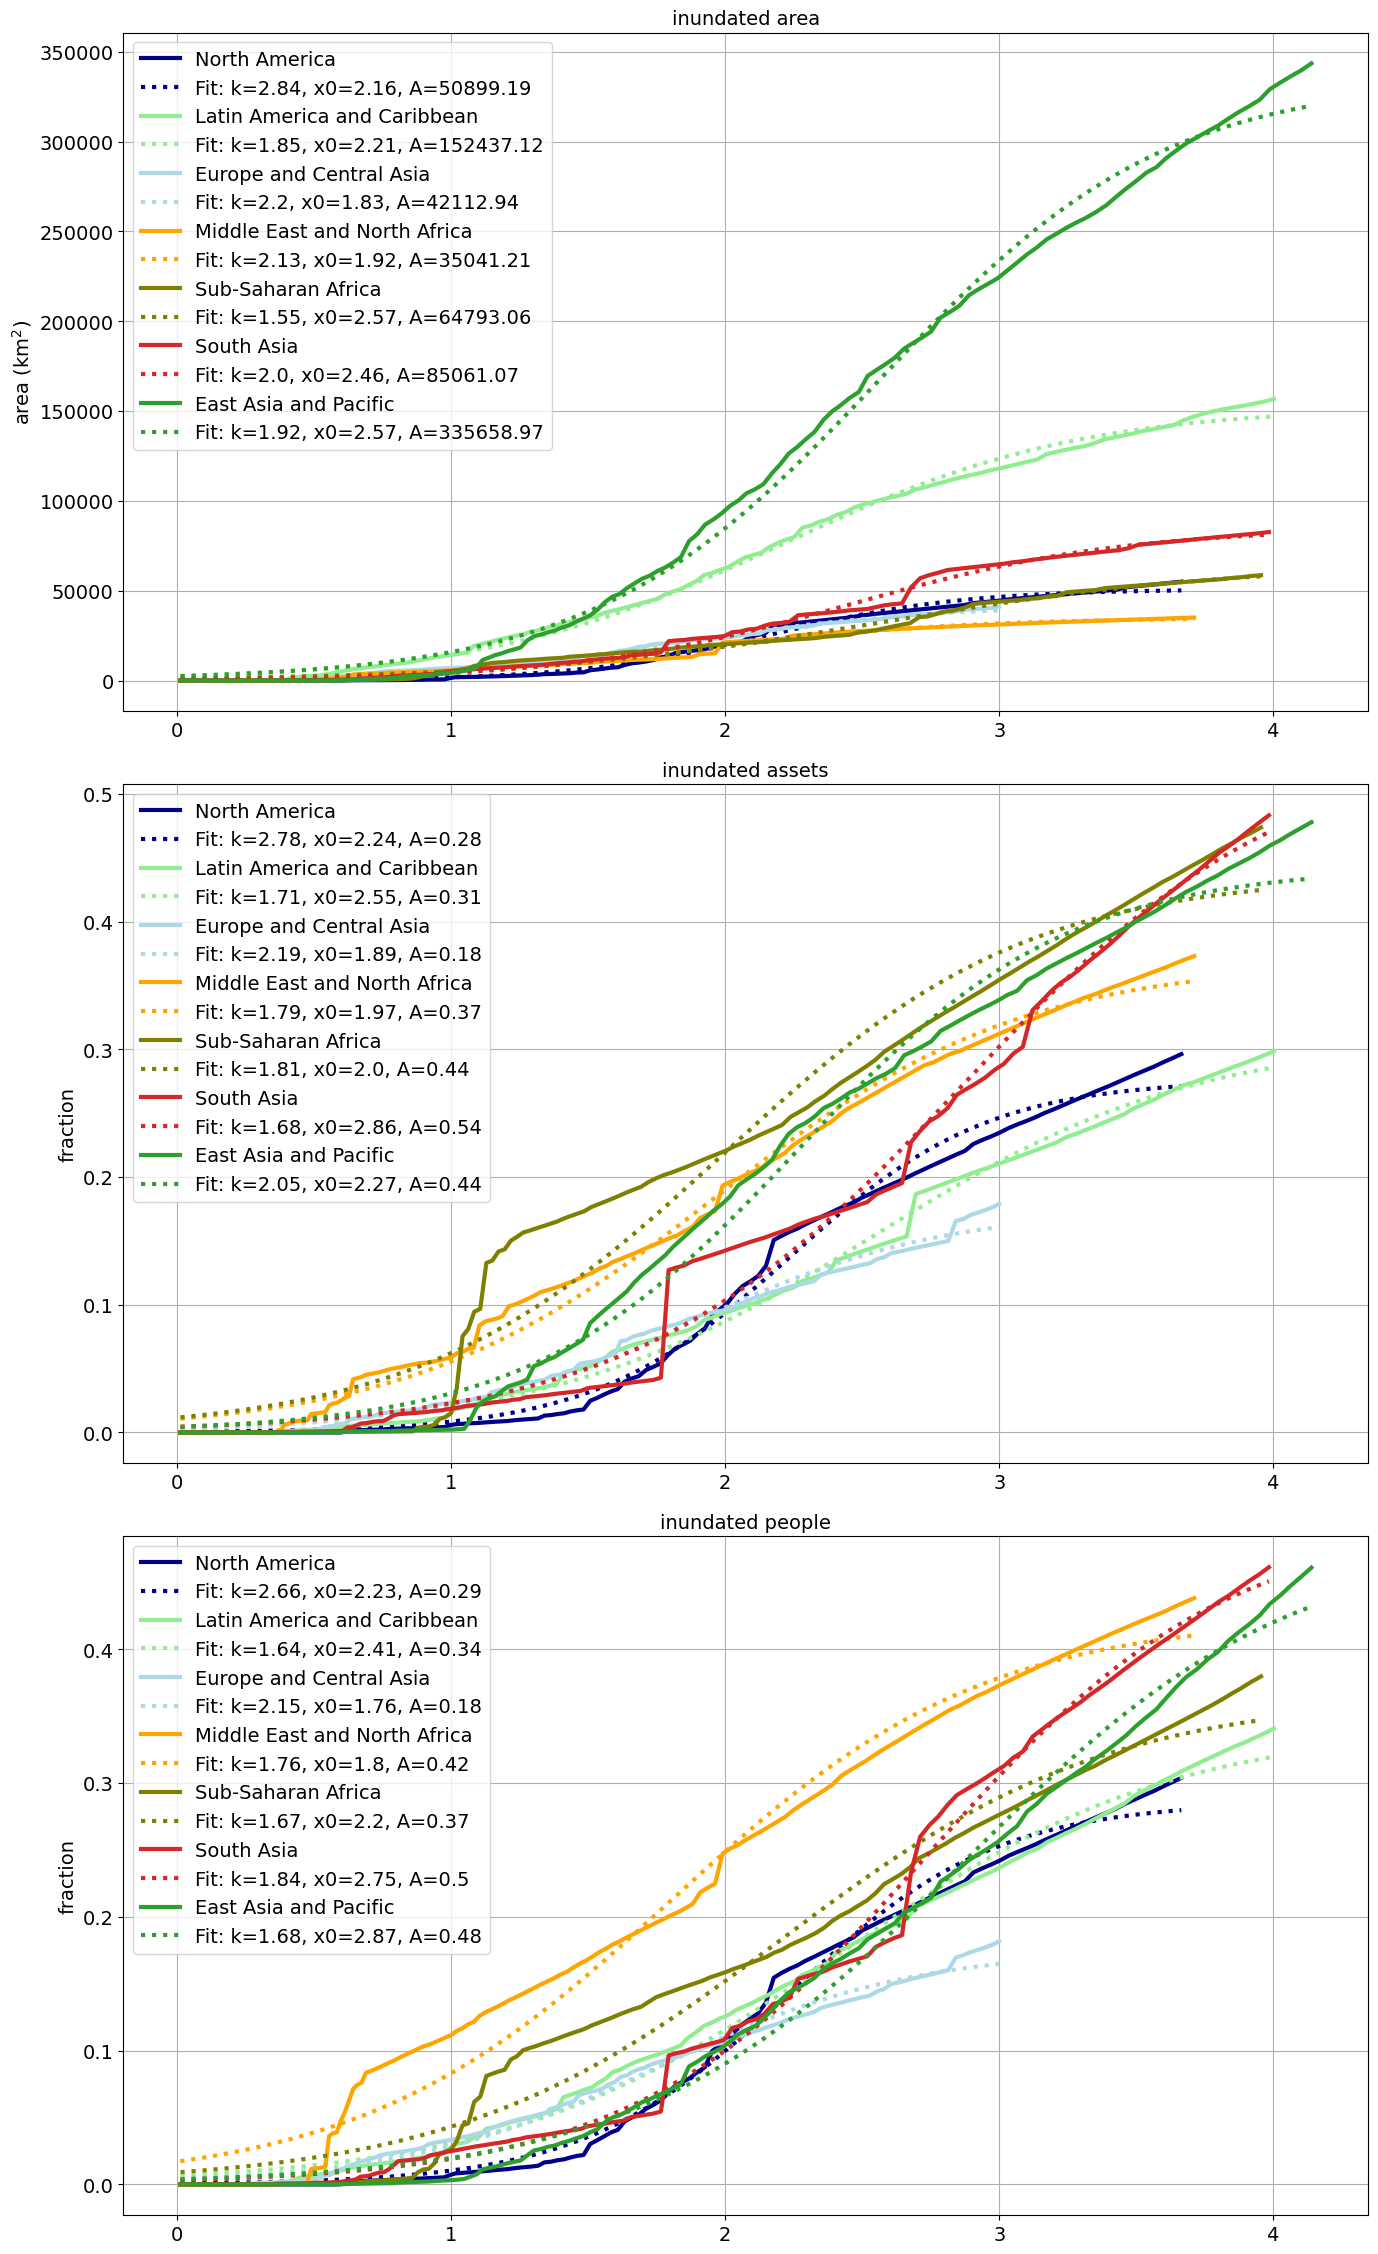

In [10]:
# data/plot loop
data = [inundated_regional_area, inundated_regional_assets, inundated_regional_people]
fit_params = [area_fit_params, asset_fit_params, people_fit_params]

data2 = [inundated_regional_area2, inundated_regional_assets2, inundated_regional_people2]
fit_params2 = [area_fit_params2, asset_fit_params2, people_fit_params2]

ylabels=['area (km$^2$)', 'fraction', 'fraction']
titles=['inundated area', 'inundated assets', 'inundated people']

colors=['darkblue', 'lightgreen', 'lightblue', 'orange', 'olive', 'tab:red', 'tab:green']
labels=region_names

wInitialFP = True
woInitialFP = False
wFit = True

font=14
plt.figure(figsize=(14,30), facecolor='white')
plt.rcParams.update({'font.size': font})
plt.rc('xtick', labelsize=font)
plt.rc('ytick', labelsize=font)

for idat, dat in enumerate(data):
    plt.subplot(411+idat)
    ax=plt.gca()
    ax.set_title(titles[idat], fontsize=font)
    #ax.set_xlim(0,3)
    ax.set_ylabel(ylabels[idat], fontsize=font)
    for ireg, region in enumerate(region_names):
        if wInitialFP:
            ax.plot(ref_SLR[ireg], dat[ireg], linewidth=3, label=labels[ireg], color=colors[ireg])
            if wFit: ax.plot(ref_SLR[ireg], logistic_function2(ref_SLR[ireg], k=fit_params[idat][ireg,0], x0=fit_params[idat][ireg,1], A=fit_params[idat][ireg,2]), linewidth=3, linestyle=':',
                             label='Fit: k='+str(np.round(fit_params[idat][ireg,0],2))+', x0='+str(np.round(fit_params[idat][ireg,1],2))+', A='+str(np.round(fit_params[idat][ireg,2],2)), 
                             color=colors[ireg])
        if woInitialFP:
            ax.plot(ref_SLR[ireg], data2[idat][ireg], linewidth=3, label=labels[ireg]+' w/o initial fp', color=colors[ireg], alpha=0.4)
            
            if wFit: ax.plot(ref_SLR[ireg], log_function(ref_SLR[ireg], a=fit_params2[idat][ireg,0], b=fit_params2[idat][ireg,1]), linewidth=3, linestyle=':',
                             label='Fit: a='+str(np.round(fit_params2[idat][ireg,0],2))+', b='+str(np.round(fit_params2[idat][ireg,1],2)),
                             color=colors[ireg], alpha=0.4)


    ax.grid(which='major')
    ax.legend()

plt.tight_layout()
plt.show()

## Susceptibility and annual exposure

In [11]:
# --------------------------------------------------------------
#  Worker function – does the work for ONE sea‑level value
# --------------------------------------------------------------
def _worker(islr: int):
    """
    Compute all six quantities for a single index `islr`.
    Returns a tuple:
        (islr,
         asset_susceptibility, people_susceptibility, asset_exposure_likelihood, people_exposure_likelihood,
         asset_susceptibility2, people_susceptibility2, asset_exposure_likelihood2, people_exposure_likelihood2)
    """
        
    lsl = local_SLRs[islr,:,-1]

    people_susceptibility      = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl+surge1000, seg_H_init, pop_init), 0.0)) / regional_pop[:,0,0]
    asset_susceptibility       = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl+surge1000, seg_H_init, cap_init), 0.0)) / regional_cap[:,0,0]
    people_exposure_likelihood = np.bincount(regional_mask, weights=np.where(seg_mask, calc_exposure_SLIIDERS(lsl, seg_H_init, surge10000, pop_init, seg_gumbel, pop=True, scalar=False), 0.0)) / regional_pop[:,0,0]
    asset_exposure_likelihood  = np.bincount(regional_mask, weights=np.where(seg_mask, calc_exposure_SLIIDERS(lsl, seg_H_init, surge10000, cap_init, seg_gumbel, pop=False, scalar=False), 0.0)) / regional_cap[:,0,0]

    people_susceptibility2      = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl+surge1000, 0, pop_init), 0.0)) / regional_pop[:,0,0]
    asset_susceptibility2       = np.bincount(regional_mask, weights=np.where(seg_mask, calc_flooding_SLIIDERS(lsl+surge1000, 0, cap_init), 0.0)) / regional_cap[:,0,0]
    people_exposure_likelihood2 = np.bincount(regional_mask, weights=np.where(seg_mask, calc_exposure_SLIIDERS(lsl, 0, surge10000, pop_init, seg_gumbel, pop=True, scalar=False), 0.0)) / regional_pop[:,0,0]
    asset_exposure_likelihood2  = np.bincount(regional_mask, weights=np.where(seg_mask, calc_exposure_SLIIDERS(lsl, 0, surge10000, cap_init, seg_gumbel, pop=False, scalar=False), 0.0)) / regional_cap[:,0,0]

    return (islr, asset_susceptibility, people_susceptibility, asset_exposure_likelihood, people_exposure_likelihood,
         asset_susceptibility2, people_susceptibility2, asset_exposure_likelihood2, people_exposure_likelihood2)


ref_SLR_regional = regional_slr[:,:,-1]

print('Starting the calculations of susceptibily and exposure fractions')
start = timer.time()

# Parallelized loop
results = Parallel(n_jobs=-1, backend='loky', batch_size=1, verbose=10)(
    delayed(_worker)(islr) for islr in range(n_time_ext))


asset_regional_fraction = np.zeros((nreg,n_time_ext))
people_regional_fraction = np.zeros((nreg,n_time_ext))
asset_regional_fraction2 = np.zeros((nreg,n_time_ext))
people_regional_fraction2 = np.zeros((nreg,n_time_ext))

asset_regional_likelihood = np.zeros((nreg,n_time_ext))
people_regional_likelihood = np.zeros((nreg,n_time_ext))
asset_regional_likelihood2 = np.zeros((nreg,n_time_ext))
people_regional_likelihood2 = np.zeros((nreg,n_time_ext))

for (islr,
     asset_sus, people_sus, asset_like, people_like,
     asset_sus2, people_sus2, asset_like2, people_like2) in results:

    asset_regional_fraction[:,islr]    = asset_sus
    people_regional_fraction[:,islr]   = people_sus
    asset_regional_likelihood[:,islr]  = asset_like
    people_regional_likelihood[:,islr] = people_like

    asset_regional_fraction2[:,islr]    = asset_sus2
    people_regional_fraction2[:,islr]   = people_sus2
    asset_regional_likelihood2[:,islr]  = asset_like2
    people_regional_likelihood2[:,islr] = people_like2

    
print('...finished, took',  np.round(timer.time()-start,2), 'seconds!')


Starting the calculations of susceptibily and exposure fractions


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 256 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of 201 | elapsed:  2.8min remaining: 107.8min
[Parallel(n_jobs=-1)]: Done  26 out of 201 | elapsed:  3.1min remaining: 20.6min
[Parallel(n_jobs=-1)]: Done  47 out of 201 | elapsed:  3.3min remaining: 10.8min
[Parallel(n_jobs=-1)]: Done  68 out of 201 | elapsed:  3.4min remaining:  6.7min
[Parallel(n_jobs=-1)]: Done  89 out of 201 | elapsed:  3.5min remaining:  4.5min
[Parallel(n_jobs=-1)]: Done 110 out of 201 | elapsed:  3.6min remaining:  3.0min
[Parallel(n_jobs=-1)]: Done 131 out of 201 | elapsed:  3.8min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done 152 out of 201 | elapsed:  3.8min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done 173 out of 201 | elapsed:  3.9min remaining:   37.5s
[Parallel(n_jobs=-1)]: Done 194 out of 201 | elapsed:  3.9min remaining:    8.5s


...finished, took 235.99 seconds!


[Parallel(n_jobs=-1)]: Done 201 out of 201 | elapsed:  3.9min finished


In [12]:
asset_fit_params = np.zeros((nreg,4))
people_fit_params = np.zeros((nreg,4))
asset_fit_stdev = np.zeros((nreg,4))
people_fit_stdev = np.zeros((nreg,4))

asset_fit_params2 = np.zeros((nreg,3))
people_fit_params2 = np.zeros((nreg,3))
asset_fit_stdev2 = np.zeros((nreg,3))
people_fit_stdev2 = np.zeros((nreg,3))

asset_likelihood_fit_params = np.zeros((nreg,4))
people_likelihood_fit_params = np.zeros((nreg,4))
asset_likelihood_fit_stdev = np.zeros((nreg,4))
people_likelihood_fit_stdev = np.zeros((nreg,4))

asset_likelihood_fit_params2 = np.zeros((nreg,3))
people_likelihood_fit_params2 = np.zeros((nreg,3))
asset_likelihood_fit_stdev2 = np.zeros((nreg,3))
people_likelihood_fit_stdev2 = np.zeros((nreg,3))

# Create some initial guesses to make sure that fit is good
p0s = np.zeros((nreg,4))
p0s2 = np.zeros((nreg,3))

guess_p0s = np.asarray([1.5, 0.0, 0.20, 0])
guess_p0s2 = np.asarray([0.2, 0.3, 0.3])

p0s[:,:] = guess_p0s[np.newaxis,:]
p0s2[:,:] = guess_p0s2[np.newaxis,:]

for ireg in range(nreg):
    print(region_names[ireg])
    # Generally suscpetible fractions
    asset_p, cov = curve_fit(logistic_function2, ref_SLR_regional[ireg, :], asset_regional_fraction[ireg, :], maxfev=10000, p0=p0s[ireg])
    asset_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    people_p, cov = curve_fit(logistic_function2, ref_SLR_regional[ireg, :], people_regional_fraction[ireg, :], maxfev=10000, p0=p0s[ireg])
    people_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    
    asset_fit_params[ireg,:] = asset_p[:]
    people_fit_params[ireg,:] = people_p[:]
    
    asset_p, cov = curve_fit(log_function2, ref_SLR_regional[ireg, :], asset_regional_fraction2[ireg, :], maxfev=10000, p0=p0s2[ireg])
    asset_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))
    people_p, cov = curve_fit(log_function2, ref_SLR_regional[ireg, :], people_regional_fraction2[ireg, :], maxfev=10000, p0=p0s2[ireg])
    people_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))

    asset_fit_params2[ireg,:] = asset_p[:]
    people_fit_params2[ireg,:] = people_p[:]
    
    
    # Exposure likelihoods
    asset_p, cov = curve_fit(logistic_function2, ref_SLR_regional[ireg, :], asset_regional_likelihood[ireg, :], maxfev=100000, p0=p0s[ireg])
    asset_likelihood_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    people_p, cov = curve_fit(logistic_function2, ref_SLR_regional[ireg, :], people_regional_likelihood[ireg, :], maxfev=100000, p0=p0s[ireg])
    people_likelihood_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))
    
    asset_likelihood_fit_params[ireg,:] = asset_p[:]
    people_likelihood_fit_params[ireg,:] = people_p[:]
    
    asset_p, cov = curve_fit(log_function2, ref_SLR_regional[ireg, :], asset_regional_likelihood2[ireg, :], maxfev=100000, p0=p0s2[ireg])
    asset_likelihood_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))
    people_p, cov = curve_fit(log_function2, ref_SLR_regional[ireg, :], people_regional_likelihood2[ireg, :], maxfev=100000, p0=p0s2[ireg])
    people_likelihood_fit_stdev2[ireg,:] = np.sqrt(np.diag(cov))
    
    asset_likelihood_fit_params2[ireg,:] = asset_p[:]
    people_likelihood_fit_params2[ireg,:] = people_p[:]
    
    #### Fill in the fit parameters for storm surge susceptibility and exposure
    fit_params_with_initial_dikes[ireg,3:,:4] = np.asarray([asset_fit_params[ireg], people_fit_params[ireg], asset_likelihood_fit_params[ireg], people_likelihood_fit_params[ireg]])
    fit_params_without_initial_dikes[ireg,3:,:3] = np.asarray([asset_fit_params2[ireg], people_fit_params2[ireg], asset_likelihood_fit_params2[ireg], people_likelihood_fit_params2[ireg]])

    fit_params_with_initial_dikes[ireg,3:,4:] = np.asarray([asset_fit_stdev[ireg], people_fit_stdev[ireg], asset_likelihood_fit_params[ireg], people_likelihood_fit_stdev[ireg]])
    fit_params_without_initial_dikes[ireg,3:,3:] = np.asarray([asset_fit_stdev2[ireg], people_fit_stdev2[ireg], asset_likelihood_fit_params2[ireg], people_likelihood_fit_stdev2[ireg]])


/work/mh0033/m300732/SLR/FRISIA/processing/helpers.py:349: RuntimeWarning: invalid value encountered in log
  return a*np.log(x*b+1)+c


North America
Latin America and Caribbean
Europe and Central Asia
Middle East and North Africa
Sub-Saharan Africa


/tmp/ipykernel_3814791/1542569840.py:55: RuntimeWarning: invalid value encountered in sqrt
  people_likelihood_fit_stdev[ireg,:] = np.sqrt(np.diag(cov))


South Asia
East Asia and Pacific


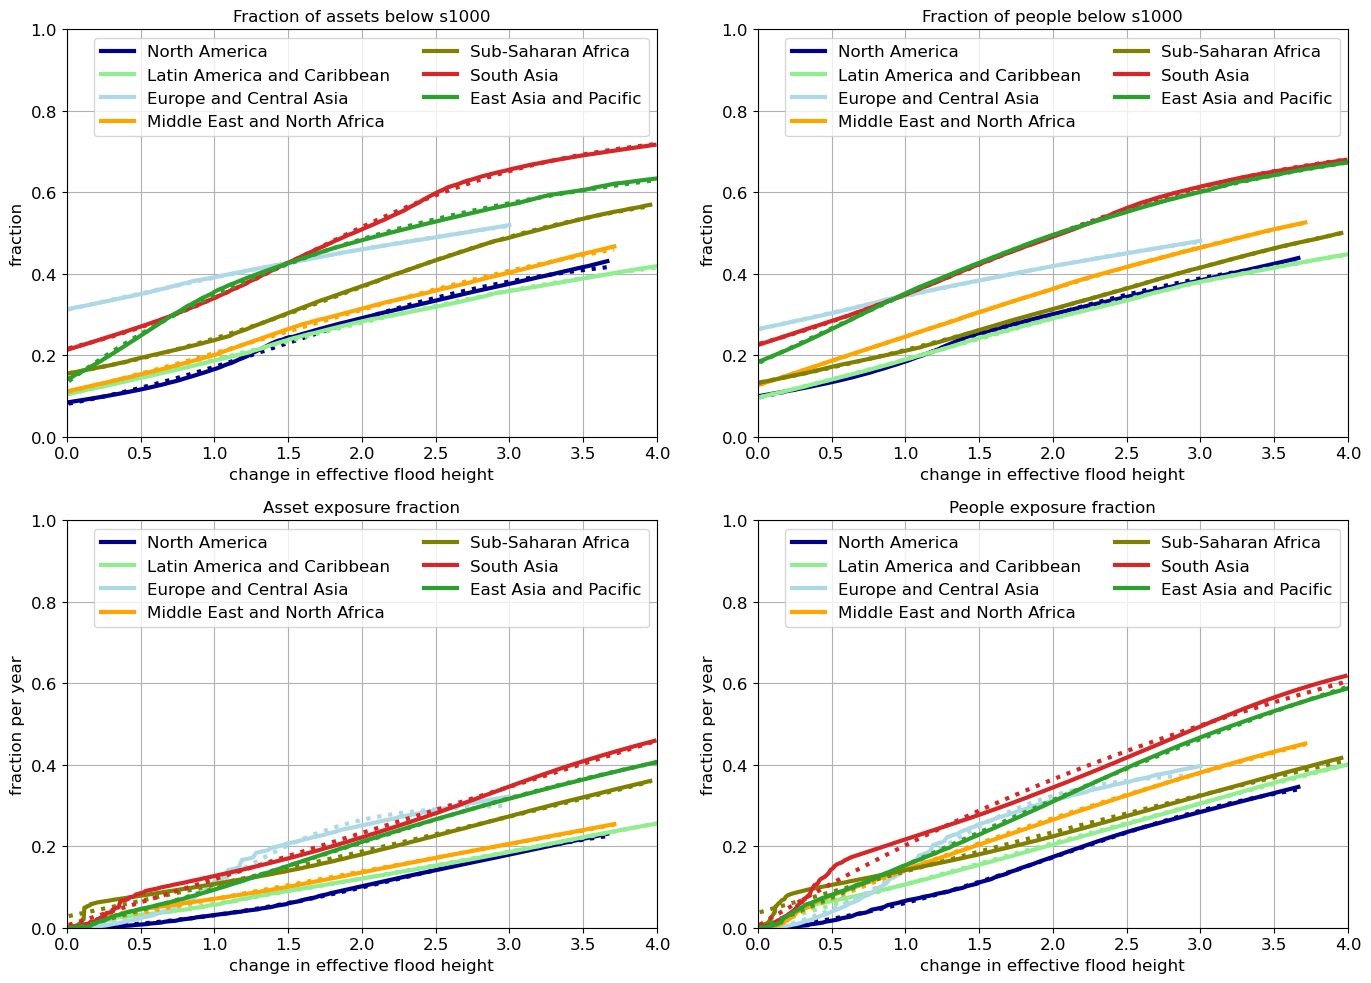

In [13]:
# data/plot loop
# data/plot loop
data = [asset_regional_fraction, people_regional_fraction, asset_regional_likelihood, people_regional_likelihood]
fit_params = [asset_fit_params, people_fit_params, asset_likelihood_fit_params, people_likelihood_fit_params]

data2 = [asset_regional_fraction2, people_regional_fraction2, asset_regional_likelihood2, people_regional_likelihood2]
fit_params2 = [asset_fit_params2, people_fit_params2, asset_likelihood_fit_params2, people_likelihood_fit_params2]


ylabels=['fraction', 'fraction', 'fraction per year', 'fraction per year']
titles=['Fraction of assets below s1000',
        'Fraction of people below s1000',
        'Asset exposure fraction',
        'People exposure fraction']

wFit = True
wInitialFP = True
woInitialFP = False

labels=region_names
colors_reg=colors

font=12
plt.figure(figsize=(14,10), facecolor='white')
plt.rcParams.update({'font.size': font})
plt.rc('xtick', labelsize=font)
plt.rc('ytick', labelsize=font)

for idat, dat in enumerate(data):
    plt.subplot(221+idat)
    ax=plt.gca()
    ax.set_title(titles[idat], fontsize=font)
    ax.set_xlim(0,4)
    ax.set_xlabel('change in effective flood height')
    ax.set_ylim(0,1)
    #else:
    #    ax.set_ylim(0,5)
    ax.set_ylabel(ylabels[idat], fontsize=font)
    for ireg in range(nreg):
        
        if wInitialFP:
            ax.plot(ref_SLR_regional[ireg], data[idat][ireg], linewidth=3, label=labels[ireg], color=colors_reg[ireg])
            if wFit:
                ax.plot(ref_SLR_regional[ireg], logistic_function2(ref_SLR_regional[ireg], k=fit_params[idat][ireg,0], x0=fit_params[idat][ireg,1], A=fit_params[idat][ireg,2], c=fit_params[idat][ireg,3]), linewidth=3,
                        #label='Fit: k='+str(np.round(fit_params[idat][ireg,0],2))+', x0='+str(np.round(fit_params[idat][ireg,1],2))+', A='+str(np.round(fit_params[idat][ireg,2],2))+', c='+str(np.round(fit_params[idat][ireg,3],2)),
                        label='',
                        linestyle=':', color=colors_reg[ireg])
        
        
        if woInitialFP:
            ax.plot(ref_SLR_regional[ireg], data2[idat][ireg], linewidth=3, label=labels[ireg]+' w/o initial fp', color=colors[ireg], alpha=0.4)
            if wFit:
                ax.plot(ref_SLR_regional[ireg, :], log_function2(ref_SLR_regional[ireg, :], a=fit_params2[idat][ireg,0], b=fit_params2[idat][ireg,1], c=fit_params2[idat][ireg,2]), linewidth=3,
                        label='Fit: a='+str(np.round(fit_params2[idat][ireg,0],2))+', b='+str(np.round(fit_params2[idat][ireg,1],2))+', c='+str(np.round(fit_params2[idat][ireg,2],2)),
                        linestyle=':', color=colors[ireg])    

        
    ax.grid(which='major')
    ax.legend(ncol=2, fontsize=font)


plt.tight_layout()
plt.show()

## Write the fit parameters into files

In [14]:
fit_functions = ['inund_params_area', 'inund_params_assets', 'inund_params_people', 
                 'storm_suscept_params_assets', 'storm_suscept_params_people', 
                 'storm_exposure_params_assets', 'storm_exposure_params_people']

outpath = inputFRISIA+'fit_function_parameters/'

for ifit, fit_function in enumerate(fit_functions):
    # Make files for each fit function with global aggregation and initial flood protection  
    
    ########### Regional aggregation
    regions = region_names
    
    data = {
        'Region': regions
    }

    data['k']  = fit_params_with_initial_dikes[:,ifit,0]
    data['x0'] = fit_params_with_initial_dikes[:,ifit,1]
    data['A']  = fit_params_with_initial_dikes[:,ifit,2]
    data['c']  = fit_params_with_initial_dikes[:,ifit,3]

    data['k SD']  = fit_params_with_initial_dikes[:,ifit,4]
    data['x0 SD'] = fit_params_with_initial_dikes[:,ifit,5]
    data['A SD']  = fit_params_with_initial_dikes[:,ifit,6]
    data['c SD']  = fit_params_with_initial_dikes[:,ifit,7]
    
    df = pd.DataFrame(data)
    df.to_csv(outpath+AggregationName+'_'+fit_function+'.csv', index=False)
    data = {
        'Region': regions
    }

    data['a'] = fit_params_without_initial_dikes[:,ifit,0]
    data['b'] = fit_params_without_initial_dikes[:,ifit,1]
    data['c'] = fit_params_without_initial_dikes[:,ifit,2]
    
    data['a SD'] = fit_params_without_initial_dikes[:,ifit,3]
    data['b SD'] = fit_params_without_initial_dikes[:,ifit,4]
    data['c SD'] = fit_params_without_initial_dikes[:,ifit,5]
    
    df = pd.DataFrame(data)
    
    df.to_csv(outpath+AggregationName+'_'+fit_function+'_no_initial_dikes.csv', index=False)

    
        

## SLR analysis (regional and/or wheighted vs calculated global)

In [15]:
from scipy.optimize import curve_fit

def linear_fit(x,a):
    return a*x

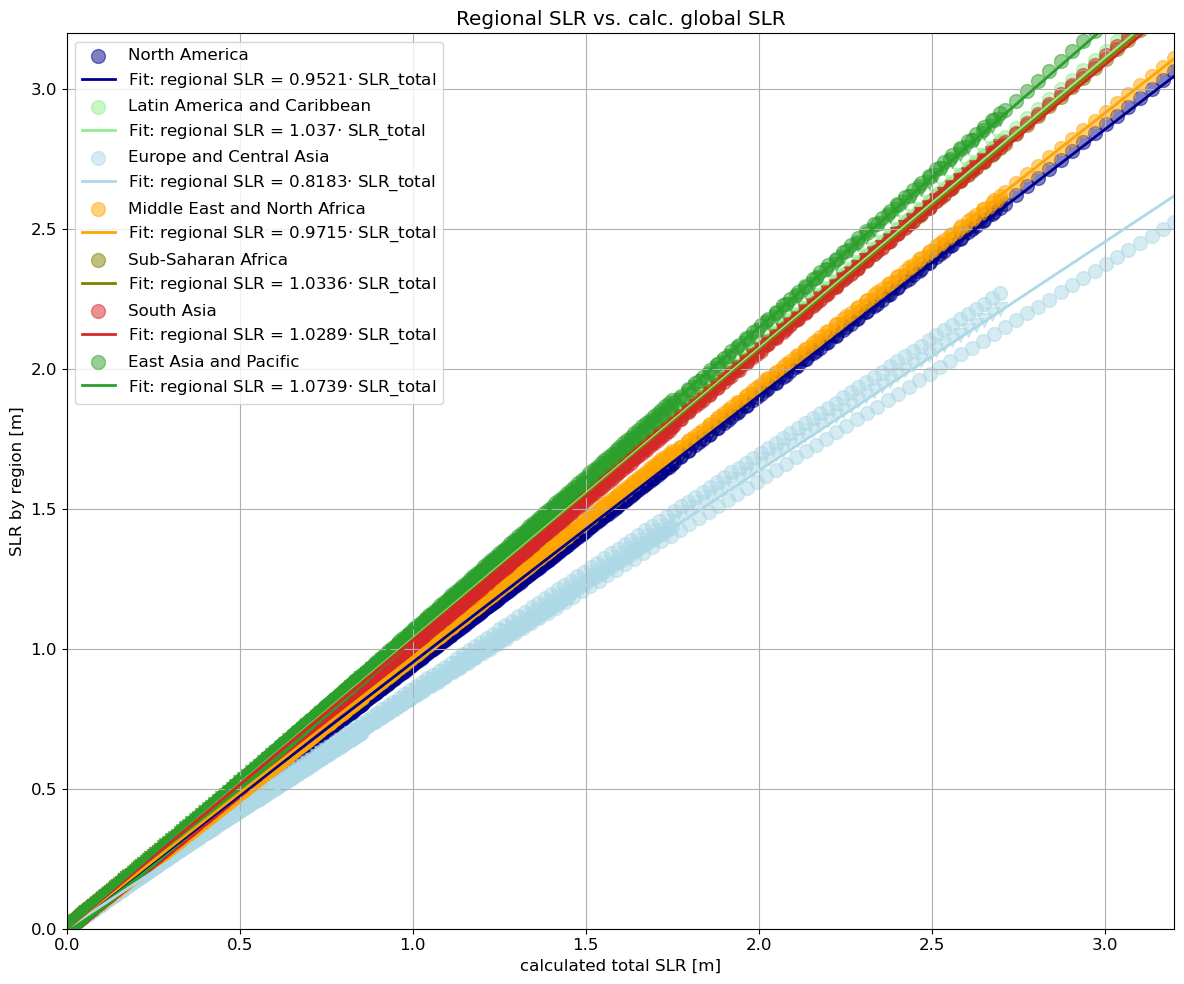

In [16]:
x = np.linspace(0, 3.2,100)
SLR_factors=np.zeros((nreg))

for i in range(nreg):
    SLR_factors[i], dum = curve_fit(linear_fit, SLR_total[:,:].flatten(), regional_slr[i].flatten())

def calcSLR(SLRs, weights):
    return np.sum(np.asarray(SLRs)[:,np.newaxis,:]*np.asarray(weights)[:,:,np.newaxis], axis=0)

SLRs = [SLR_thermo[:,2], SLR_LWS[:,2], SLR_MG[:,2], SLR_GIS[:,2], SLR_AIS[:,2]]
weights = [np.ones(nreg), np.ones(nreg), regional_wt_MG, regional_wt_GIS, regional_wt_AIS]
calc_regional_slr = calcSLR(SLRs, weights)


font=12
plt.figure(figsize=(12,10), facecolor='white')
plt.rcParams.update({'font.size': font})
plt.rc('xtick', labelsize=font)
plt.rc('ytick', labelsize=font)

ax=plt.gca()
ax.set_ylabel('SLR by region [m]')
ax.set_xlabel('calculated total SLR [m]')
ax.set_xlim(0,3.2)
ax.set_ylim(0,3.2)
ax.set_title('Regional SLR vs. calc. global SLR')

for i, region in enumerate(region_names):
    ax.scatter(SLR_total[:,:].flatten(), regional_slr[i].flatten(), color=colors[i], alpha=0.5, label=region, s=100)
    ax.scatter(SLR_total[:,2], calc_regional_slr[i], color=colors[i], alpha=0.5, label='', marker='v', s=100)
    
    ax.plot(x, linear_fit(x,SLR_factors[i]), color=colors[i], lw=2, label='Fit: regional SLR = '+str(np.round(SLR_factors[i],4))+'$\cdot$ SLR_total')

ax.grid()   
ax.legend()

#ax.set_xlim(0.7,1.0)
#ax.set_ylim(0.5,1.2)

plt.tight_layout()
plt.show()

## Also write the DIVA information into files

In [17]:
variables = ['SLR_factor', 'SLR_weight_MG', 'SLR_weight_GIS', 'SLR_weight_AIS', 'average_fp_height', 'total_fp_length', 'surge1_height', 'surge10_height', 'surge100_height', 'surge1000_height', 'population_fraction', 'asset_fraction']

outpath = inputFRISIA+'aggregated_data/'



########### Regional aggregation

data = {
    'Region': region_names
}

values = [SLR_factors, regional_wt_MG, regional_wt_GIS, regional_wt_AIS,
          dike_height_by_region[:], coast_length_by_region[:], 
          surge1_by_region[:], surge10_by_region[:], surge100_by_region[:], surge1000_by_region[:],
          regional_pop[:,0,0]/global_pop[0,0], regional_cap[:,0,0]/global_cap[0,0]]

for ivar, variable in enumerate(variables): data[variable] = values[ivar]

df = pd.DataFrame(data)
df.to_csv(outpath+AggregationName+'_information.csv', index=False)



## Population and GDP analysis
##### Here, just prepare the required data in a new csv file

In [18]:
data = {
    'Time': np.linspace(2000,2200,201)
}

for isc, scenario in enumerate(scenarios):
    
    data['Coastal GDP (global) '+scenario] = global_gdp[:,isc]*1.0e-9
    for ireg, region in enumerate(region_names) : data['Coastal GDP ('+region+') '+scenario] = regional_gdp[ireg,:,isc]*1.0e-9

    data['Coastal Capital (global) '+scenario] = global_cap[:,isc]*1.0e-9
    for ireg, region in enumerate(region_names) : data['Coastal Capital ('+region+') '+scenario] = regional_cap[ireg,:,isc]*1.0e-9
    
    data['Coastal pop (global) '+scenario] = global_pop[:,isc]*1.0e-6
    for ireg, region in enumerate(region_names) : data['Coastal pop ('+region+') '+scenario] = regional_pop[ireg,:,isc]*1.0e-6


df = pd.DataFrame(data)
df.to_csv(inputFRISIA+AggregationName+'_external_data.csv', index=False)

df.head()

,Time,Coastal GDP (global) ssp126,Coastal GDP (North America) ssp126,Coastal GDP (Latin America and Caribbean) ssp126,Coastal GDP (Europe and Central Asia) ssp126,Coastal GDP (Middle East and North Africa) ssp126,Coastal GDP (Sub-Saharan Africa) ssp126,Coastal GDP (South Asia) ssp126,Coastal GDP (East Asia and Pacific) ssp126,Coastal Capital (global) ssp126,...,Coastal Capital (South Asia) ssp585,Coastal Capital (East Asia and Pacific) ssp585,Coastal pop (global) ssp585,Coastal pop (North America) ssp585,Coastal pop (Latin America and Caribbean) ssp585,Coastal pop (Europe and Central Asia) ssp585,Coastal pop (Middle East and North Africa) ssp585,Coastal pop (Sub-Saharan Africa) ssp585,Coastal pop (South Asia) ssp585,Coastal pop (East Asia and Pacific) ssp585
0,2000.0,11293.316343,2416.173761,759.716457,2352.013747,592.844235,103.172214,382.191409,4687.204520,58623.228052,...,2551.307255,23610.455738,951.488035,48.598527,69.075142,78.334252,37.577466,45.523869,180.495593,491.883186
1,2001.0,11511.481803,2440.964636,763.956076,2403.221100,603.162153,108.522571,398.283458,4793.371811,60601.513722,...,2722.836408,24626.036215,962.958469,49.096644,69.989035,78.634439,38.369564,46.724417,183.697287,496.447082
2,2002.0,11804.284915,2484.537258,760.603306,2442.388804,614.608467,115.362757,413.870247,4972.914077,62644.878109,...,2888.703543,25685.500959,974.282123,49.557790,70.885307,78.975357,39.185997,47.947192,186.875926,500.854553
3,2003.0,12211.239601,2554.734104,778.231185,2487.138217,657.613299,120.899803,443.484416,5169.138577,64860.728496,...,3071.073624,26879.971301,985.555391,49.997315,71.765604,79.347318,40.064362,49.202261,190.016386,505.162146
4,2004.0,12808.294555,2651.143343,827.712746,2563.371720,710.114795,128.805959,476.391970,5450.754022,67374.754146,...,3283.741620,28239.716848,996.891026,50.438462,72.631712,79.738504,41.053759,50.498119,193.100319,509.430151
